In [7]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    cross_val_predict,
    StratifiedKFold,
    learning_curve,
    validation_curve
)
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Intentar importar XGBoost
XGB_AVAILABLE = False
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print("✅ XGBoost disponible")
except ImportError:
    print("⚠️ XGBoost no instalado. Usando solo Random Forest.")
    print("   Para instalar: pip install xgboost")

# Configuración
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

BASE_DIR = Path.cwd()
if BASE_DIR.name == 'src':
    BASE_DIR = BASE_DIR.parent

# Crear directorio de figuras
(BASE_DIR / 'figures').mkdir(parents=True, exist_ok=True)

print(f"📁 Directorio base: {BASE_DIR}")

✅ XGBoost disponible
📁 Directorio base: c:\Users\leona\OneDrive\Escritorio\MachineLearnignFINALEDA\Machine-learning


In [9]:

# ============================================
# 2. CARGA DE DATOS PREPROCESADOS
# ============================================

print("\n" + "="*60)
print("CARGA DE DATOS PREPROCESADOS")
print("="*60)

# Cargar los datos limpios
df = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'Dataset_ALDIMI_Merged_Clean.csv')
print(f"✅ Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")



CARGA DE DATOS PREPROCESADOS
✅ Dataset cargado: 3000 filas, 24 columnas


In [10]:
# ============================================
# 3. PREPARACIÓN DE DATOS
# ============================================

print("\n" + "="*60)
print("PREPARACIÓN DE DATOS")
print("="*60)

# Eliminar columnas que causan data leakage
drop_cols = ['Patient_ID', 'Overall_Risk_Score', 'county_CTYNAME']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Separar features y target
X = df.drop('Risk_Level', axis=1)
y = df['Risk_Level']

# Codificar target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Clases: {le.classes_}")

# One-hot encoding para variables categóricas
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Distribución clases - Train: {np.bincount(y_train)}")
print(f"Distribución clases - Test: {np.bincount(y_test)}")



PREPARACIÓN DE DATOS
Clases: ['High' 'Low' 'Medium']
Train: (2400, 23), Test: (600, 23)
Distribución clases - Train: [ 118  387 1895]
Distribución clases - Test: [ 30  97 473]


In [11]:
# ============================================
# 4. ENTRENAMIENTO DE MODELOS
# ============================================

print("\n" + "="*60)
print("ENTRENAMIENTO DE MODELOS")
print("="*60)

# 4.1 Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 4.2 XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# 4.3 Métricas iniciales
print("\n📊 RANDOM FOREST:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")

print("\n📊 XGBOOST:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test, y_pred_xgb, average='weighted'):.4f}")


ENTRENAMIENTO DE MODELOS

📊 RANDOM FOREST:
Accuracy: 0.9433
F1-Score (weighted): 0.9395

📊 XGBOOST:
Accuracy: 0.9450
F1-Score (weighted): 0.9433


In [12]:
# ============================================
# 5. VALIDACIÓN CRUZADA (Cross-Validation)
# ============================================

print("\n" + "="*60)
print("VALIDACIÓN CRUZADA (K-Fold)")
print("="*60)

def evaluate_cross_validation(model, X, y, model_name, cv=5):
    """Evalúa un modelo usando validación cruzada"""
    
    # Stratified K-Fold para mantener distribución de clases
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    
    # Calcular métricas en cada fold
    accuracies = []
    f1_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
        # Clonar y entrenar modelo
        model_clone = model.__class__(**model.get_params())
        model_clone.fit(X_train_fold, y_train_fold)
        
        # Predecir
        y_pred_fold = model_clone.predict(X_val_fold)
        
        # Métricas
        acc = accuracy_score(y_val_fold, y_pred_fold)
        f1 = f1_score(y_val_fold, y_pred_fold, average='weighted')
        
        accuracies.append(acc)
        f1_scores.append(f1)
        
        print(f"  Fold {fold+1}: Accuracy={acc:.4f}, F1={f1:.4f}")
    
    # Estadísticas
    print(f"\n📊 {model_name} - Resultados CV:")
    print(f"  Accuracy: {np.mean(accuracies):.4f} (±{np.std(accuracies):.4f})")
    print(f"  F1-Score: {np.mean(f1_scores):.4f} (±{np.std(f1_scores):.4f})")
    print(f"  Rango: {np.min(accuracies):.4f} - {np.max(accuracies):.4f}")
    
    # Detectar sobreajuste
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    cv_acc = np.mean(accuracies)
    
    print(f"\n⚠️ Comparación para detectar sobreajuste:")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  CV Accuracy: {cv_acc:.4f}")
    print(f"  Test Accuracy: {test_acc:.4f}")
    
    if train_acc - cv_acc > 0.05:
        print(f"  ⚠️ Posible sobreajuste: Train-CV gap = {train_acc - cv_acc:.4f}")
    else:
        print(f"  ✅ Modelo estable: Train-CV gap = {train_acc - cv_acc:.4f}")
    
    return accuracies, f1_scores

# Evaluar Random Forest
print("\n🔍 RANDOM FOREST - Validación Cruzada:")
rf_cv_acc, rf_cv_f1 = evaluate_cross_validation(rf, X_train, y_train, "Random Forest", cv=5)

# Evaluar XGBoost
print("\n🔍 XGBOOST - Validación Cruzada:")
xgb_cv_acc, xgb_cv_f1 = evaluate_cross_validation(xgb, X_train, y_train, "XGBoost", cv=5)



VALIDACIÓN CRUZADA (K-Fold)

🔍 RANDOM FOREST - Validación Cruzada:
  Fold 1: Accuracy=0.9313, F1=0.9244
  Fold 2: Accuracy=0.9375, F1=0.9339
  Fold 3: Accuracy=0.9354, F1=0.9302
  Fold 4: Accuracy=0.9208, F1=0.9132
  Fold 5: Accuracy=0.9333, F1=0.9288

📊 Random Forest - Resultados CV:
  Accuracy: 0.9317 (±0.0058)
  F1-Score: 0.9261 (±0.0071)
  Rango: 0.9208 - 0.9375

⚠️ Comparación para detectar sobreajuste:
  Train Accuracy: 1.0000
  CV Accuracy: 0.9317
  Test Accuracy: 0.9433
  ⚠️ Posible sobreajuste: Train-CV gap = 0.0683

🔍 XGBOOST - Validación Cruzada:
  Fold 1: Accuracy=0.9396, F1=0.9379
  Fold 2: Accuracy=0.9479, F1=0.9461
  Fold 3: Accuracy=0.9375, F1=0.9356
  Fold 4: Accuracy=0.9437, F1=0.9412
  Fold 5: Accuracy=0.9417, F1=0.9394

📊 XGBoost - Resultados CV:
  Accuracy: 0.9421 (±0.0036)
  F1-Score: 0.9400 (±0.0035)
  Rango: 0.9375 - 0.9479

⚠️ Comparación para detectar sobreajuste:
  Train Accuracy: 1.0000
  CV Accuracy: 0.9421
  Test Accuracy: 0.9450
  ⚠️ Posible sobreajuste:


ANÁLISIS DE ERRORES EXHAUSTIVO

📊 Random Forest - ANÁLISIS DE ERRORES
--------------------------------------------------

🔍 ERRORES POR CLASE:
  Clase High: 13/30 errores (43.3%)
    → Se confunde principalmente con Medium (13 veces)
  Clase Low: 19/97 errores (19.6%)
    → Se confunde principalmente con Medium (19 veces)
  Clase Medium: 2/473 errores (0.4%)
    → Se confunde principalmente con Low (2 veces)

🔍 FALSOS POSITIVOS Y NEGATIVOS:
  Clase High: FP=0, FN=13
  Clase Low: FP=2, FN=19
  Clase Medium: FP=32, FN=2

🔍 MÉTRICAS POR CLASE:
  High:
    Precision: 1.000
    Recall: 0.567
    F1-Score: 0.723
  Low:
    Precision: 0.975
    Recall: 0.804
    F1-Score: 0.881
  Medium:
    Precision: 0.936
    Recall: 0.996
    F1-Score: 0.965


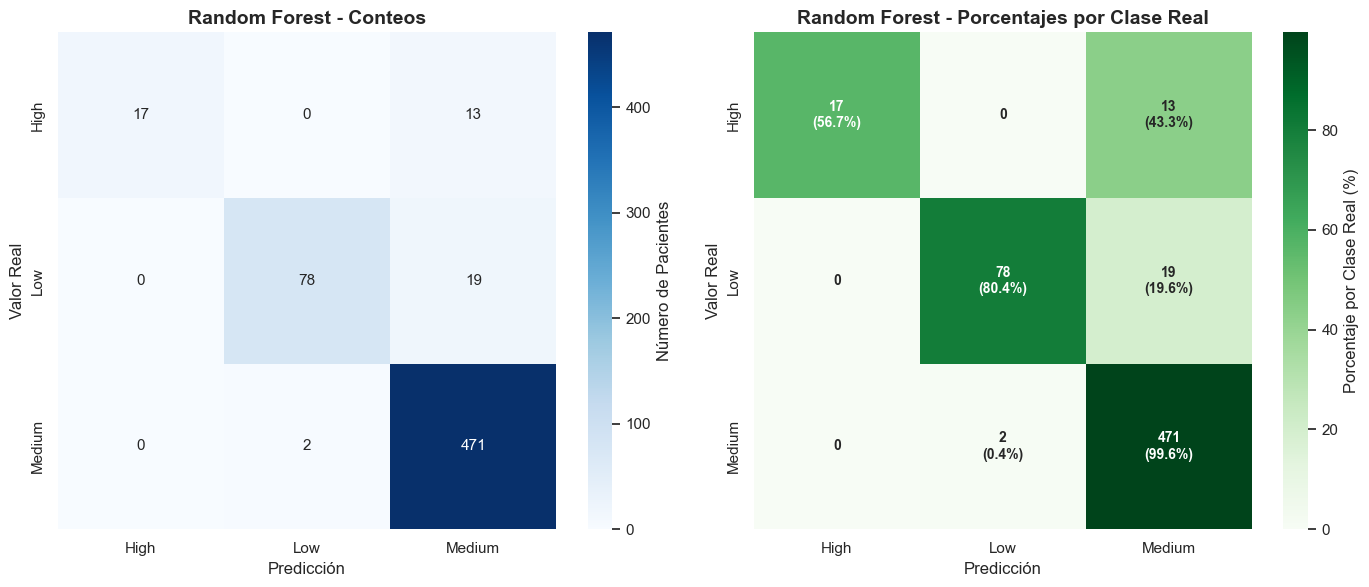

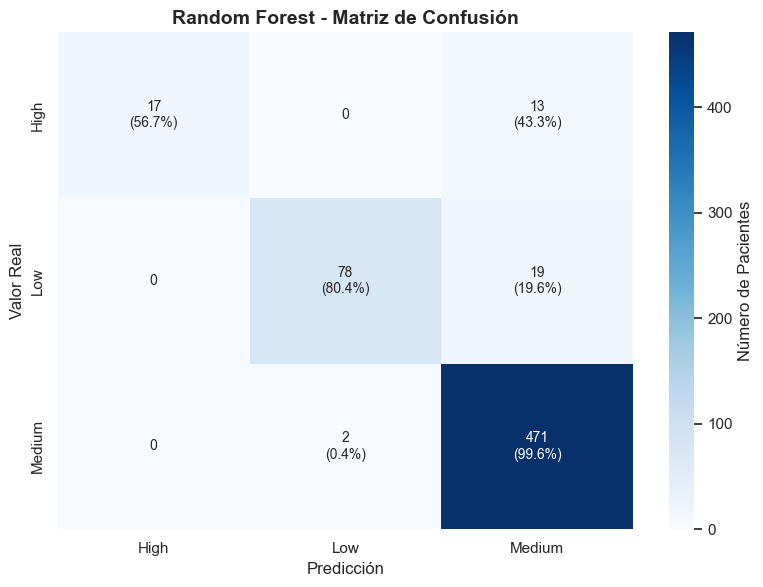


📊 XGBoost - ANÁLISIS DE ERRORES
--------------------------------------------------

🔍 ERRORES POR CLASE:
  Clase High: 10/30 errores (33.3%)
    → Se confunde principalmente con Medium (10 veces)
  Clase Low: 14/97 errores (14.4%)
    → Se confunde principalmente con Medium (14 veces)
  Clase Medium: 9/473 errores (1.9%)
    → Se confunde principalmente con Low (9 veces)

🔍 FALSOS POSITIVOS Y NEGATIVOS:
  Clase High: FP=0, FN=10
  Clase Low: FP=9, FN=14
  Clase Medium: FP=24, FN=9

🔍 MÉTRICAS POR CLASE:
  High:
    Precision: 1.000
    Recall: 0.667
    F1-Score: 0.800
  Low:
    Precision: 0.902
    Recall: 0.856
    F1-Score: 0.878
  Medium:
    Precision: 0.951
    Recall: 0.981
    F1-Score: 0.966


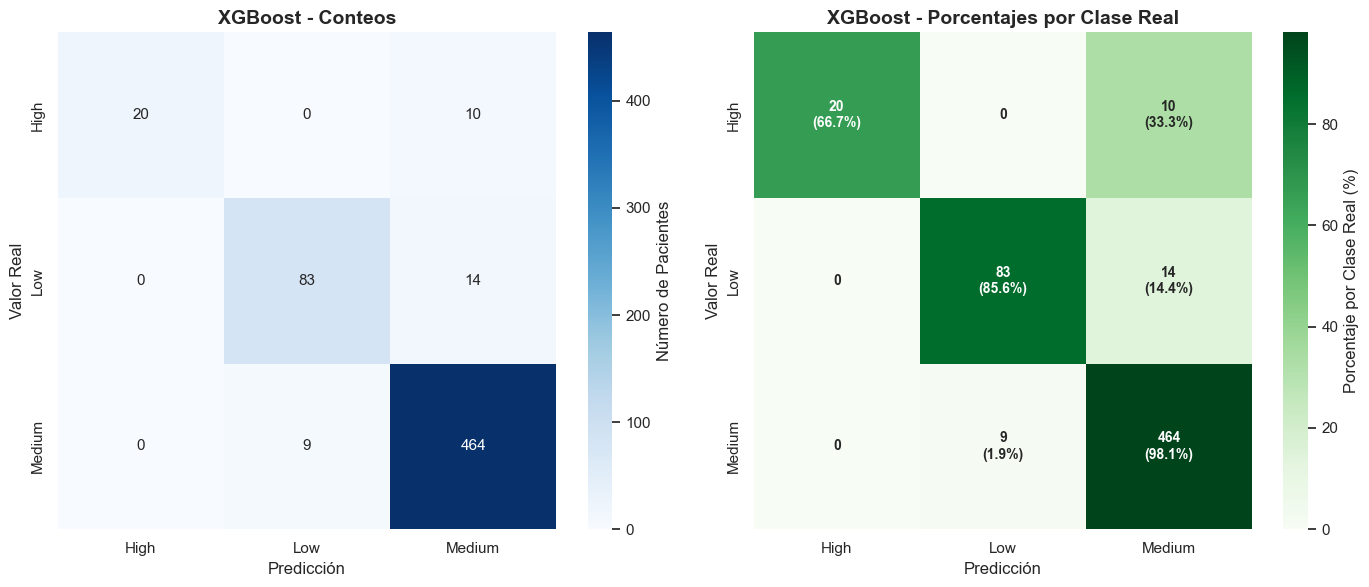

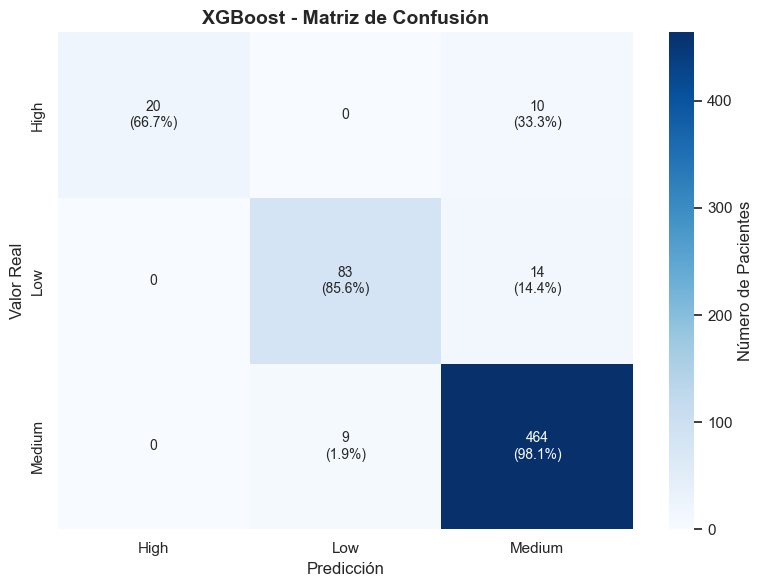

In [21]:
# ============================================
# 6. ANÁLISIS DE ERRORES EXHAUSTIVO
# ============================================

print("\n" + "="*60)
print("ANÁLISIS DE ERRORES EXHAUSTIVO")
print("="*60)

def detailed_error_analysis(y_true, y_pred, model_name, feature_names=None, X_test_data=None):
    """
    Realiza un análisis detallado de los errores del modelo
    """
    # Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n📊 {model_name} - ANÁLISIS DE ERRORES")
    print("-"*50)
    
    # Errores por clase
    print("\n🔍 ERRORES POR CLASE:")
    for i in range(cm.shape[0]):
        total_clase = cm[i, :].sum()
        correctos = cm[i, i]
        errores = total_clase - correctos
        tasa_error = errores / total_clase if total_clase > 0 else 0
        
        if errores > 0:
            confusions = cm[i, :].copy()
            confusions[i] = 0
            most_confused = np.argmax(confusions)
            print(f"  Clase {le.classes_[i]}: {errores}/{total_clase} errores ({tasa_error:.1%})")
            print(f"    → Se confunde principalmente con {le.classes_[most_confused]} ({confusions[most_confused]} veces)")
        else:
            print(f"  Clase {le.classes_[i]}: 0 errores ✅")
    
    # Falsos Positivos y Negativos
    print("\n🔍 FALSOS POSITIVOS Y NEGATIVOS:")
    for i in range(cm.shape[0]):
        fp = cm[:, i].sum() - cm[i, i]
        fn = cm[i, :].sum() - cm[i, i]
        print(f"  Clase {le.classes_[i]}: FP={fp}, FN={fn}")
    
    # Métricas por clase
    print("\n🔍 MÉTRICAS POR CLASE:")
    report = classification_report(y_true, y_pred, target_names=le.classes_, output_dict=True)
    for class_name, metrics in report.items():
        if class_name not in ['accuracy', 'macro avg', 'weighted avg']:
            print(f"  {class_name}:")
            print(f"    Precision: {metrics['precision']:.3f}")
            print(f"    Recall: {metrics['recall']:.3f}")
            print(f"    F1-Score: {metrics['f1-score']:.3f}")
    
    # ============================================
    # MATRIZ DE CONFUSIÓN MEJORADA
    # ============================================
    
    # Crear figura con dos subplots: uno para conteos y otro para porcentajes
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- Subplot 1: Conteos ---
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                cbar_kws={'label': 'Número de Pacientes'})
    ax1.set_title(f'{model_name} - Conteos', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Predicción', fontsize=12)
    ax1.set_ylabel('Valor Real', fontsize=12)
    
    # --- Subplot 2: Porcentajes por fila ---
    # Calcular porcentajes por fila (por clase real)
    cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    
    # Crear anotaciones con formato "N (X%)"
    annot_matrix = np.empty_like(cm, dtype='object')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j] > 0:
                annot_matrix[i, j] = f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)"
            else:
                annot_matrix[i, j] = "0"
    
    sns.heatmap(cm_pct, annot=annot_matrix, fmt='', cmap='Greens', ax=ax2,
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                cbar_kws={'label': 'Porcentaje por Clase Real (%)'},
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    ax2.set_title(f'{model_name} - Porcentajes por Clase Real', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Predicción', fontsize=12)
    ax2.set_ylabel('Valor Real', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'figures' / f'matriz_confusion_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # --- Versión simplificada (solo conteos con formato mejorado) ---
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Crear anotaciones con formato mejorado
    annot_clean = np.empty_like(cm, dtype='object')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j] > 0:
                pct = cm[i, j] / cm[i, :].sum() * 100
                annot_clean[i, j] = f"{cm[i, j]}\n({pct:.1f}%)"
            else:
                annot_clean[i, j] = "0"
    
    sns.heatmap(cm, annot=annot_clean, fmt='', cmap='Blues', ax=ax,
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                cbar_kws={'label': 'Número de Pacientes'},
                annot_kws={'fontsize': 10})
    ax.set_title(f'{model_name} - Matriz de Confusión', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=12)
    ax.set_ylabel('Valor Real', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'figures' / f'matriz_confusion_{model_name}_clean.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return cm

# Análisis de errores para Random Forest
feature_names = X.columns.tolist()
rf_cm = detailed_error_analysis(
    y_test, y_pred_rf, "Random Forest", 
    feature_names, X_test
)

# Análisis de errores para XGBoost (si está disponible)
if XGB_AVAILABLE:
    xgb_cm = detailed_error_analysis(
        y_test, y_pred_xgb, "XGBoost", 
        feature_names, X_test
    )


CURVAS DE APRENDIZAJE

🔍 Random Forest - Curva de Aprendizaje:


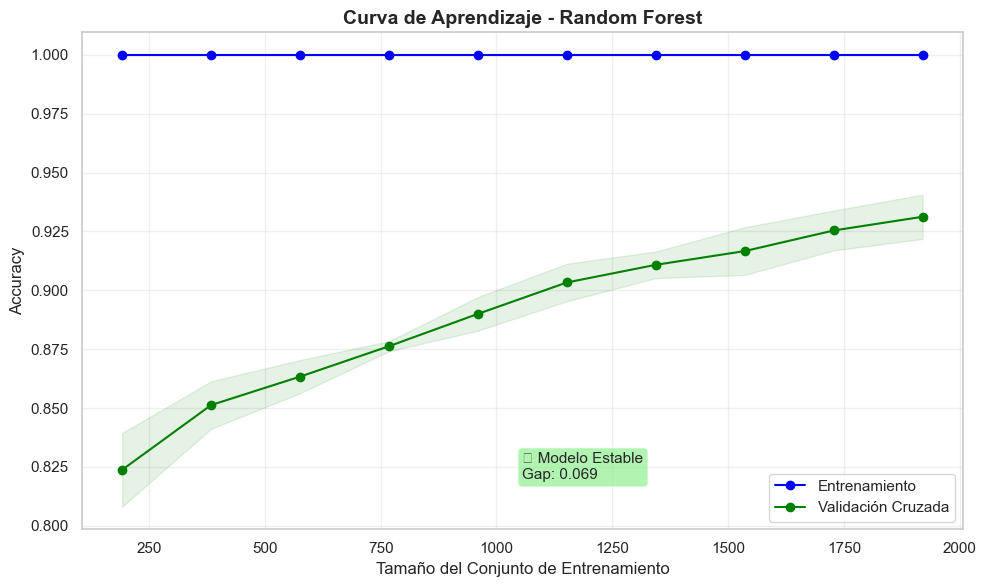


🔍 XGBoost - Curva de Aprendizaje:


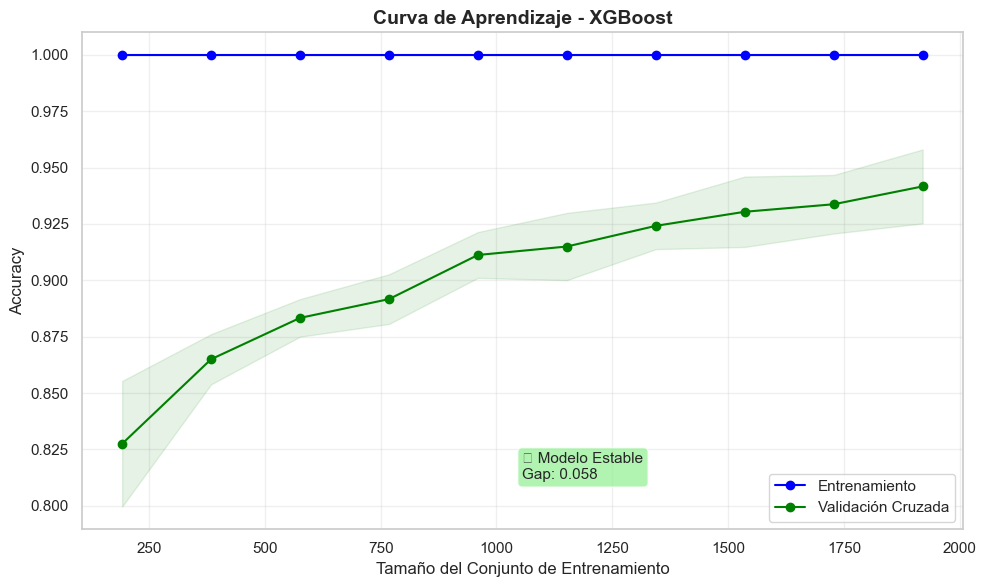

In [14]:

# ============================================
# 7. CURVAS DE APRENDIZAJE (Learning Curves)
# ============================================

print("\n" + "="*60)
print("CURVAS DE APRENDIZAJE")
print("="*60)

def plot_learning_curve(model, X, y, model_name, cv=5):
    """Genera curva de aprendizaje para detectar overfitting/underfitting"""
    
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy',
        shuffle=True,
        random_state=42
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                     alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, 
                     alpha=0.1, color='green')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Entrenamiento')
    plt.plot(train_sizes, test_mean, 'o-', color='green', label='Validación Cruzada')
    
    plt.xlabel('Tamaño del Conjunto de Entrenamiento', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title(f'Curva de Aprendizaje - {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    # Detectar problemas
    gap = train_mean[-1] - test_mean[-1]
    if gap > 0.1:
        plt.text(0.5, 0.1, f'⚠️ Posible Overfitting\nGap: {gap:.3f}', 
                 transform=plt.gca().transAxes, fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    elif train_mean[-1] < 0.7:
        plt.text(0.5, 0.1, f'⚠️ Posible Underfitting\nTrain Acc: {train_mean[-1]:.3f}', 
                 transform=plt.gca().transAxes, fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='orange', alpha=0.7))
    else:
        plt.text(0.5, 0.1, f'✅ Modelo Estable\nGap: {gap:.3f}', 
                 transform=plt.gca().transAxes, fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
    
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'figures' / f'learning_curve_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return train_mean, test_mean, gap

# Curvas de aprendizaje
print("\n🔍 Random Forest - Curva de Aprendizaje:")
rf_train, rf_test, rf_gap = plot_learning_curve(rf, X_train, y_train, "Random Forest", cv=5)

print("\n🔍 XGBoost - Curva de Aprendizaje:")
xgb_train, xgb_test, xgb_gap = plot_learning_curve(xgb, X_train, y_train, "XGBoost", cv=5)



OPTIMIZACIÓN CON REGULARIZACIÓN (Reducir Overfitting)

OPTIMIZACIÓN CON REGULARIZACIÓN - XGBoost

🔍 XGBoost - Validación de max_depth
   Rango: [2, 3, 4, 5, 6, 7, 8]

   Resultados:
      Valor |    Train Acc |       CV Acc |        Gap | Overfitting?
   ---------+--------------+--------------+------------+-------------
          2 |       0.9374 |       0.9025 |     0.0349 | ✅ NO
          3 |       0.9844 |       0.9246 |     0.0598 | ⚠️ SÍ
          4 |       0.9993 |       0.9421 |     0.0572 | ⚠️ SÍ
          5 |       1.0000 |       0.9412 |     0.0588 | ⚠️ SÍ
          6 |       1.0000 |       0.9417 |     0.0583 | ⚠️ SÍ
          7 |       1.0000 |       0.9408 |     0.0592 | ⚠️ SÍ
          8 |       1.0000 |       0.9433 |     0.0567 | ⚠️ SÍ

   ✅ Mejor valor: 2 (CV: 0.9025, Gap: 0.0349)


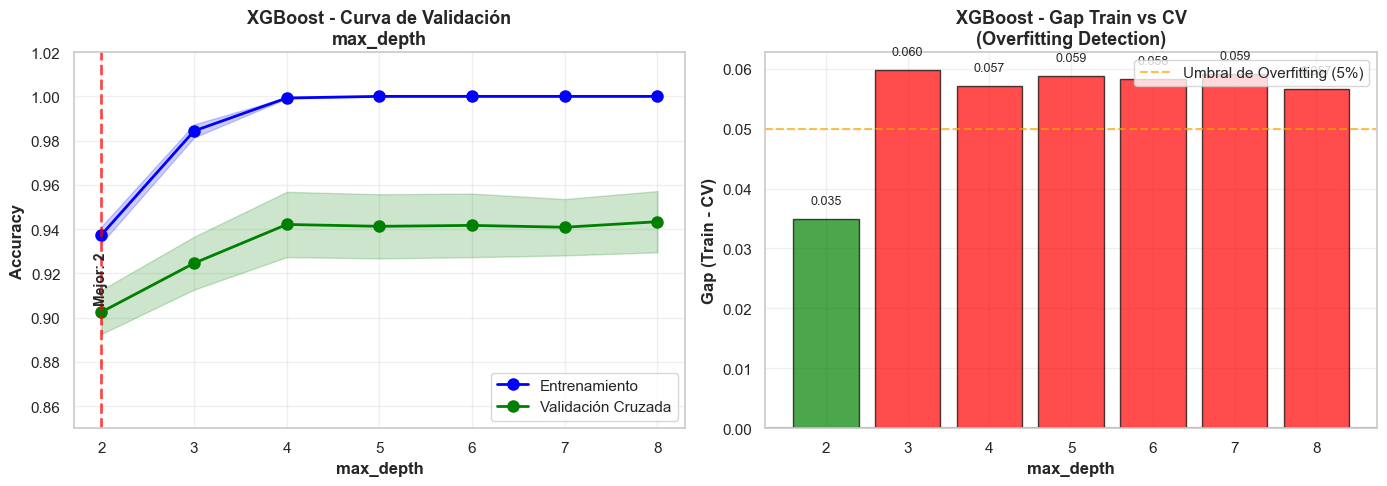


🔍 XGBoost - Validación de learning_rate
   Rango: [0.01, 0.05, 0.1, 0.2, 0.3]

   Resultados:
      Valor |    Train Acc |       CV Acc |        Gap | Overfitting?
   ---------+--------------+--------------+------------+-------------
       0.01 |       0.7896 |       0.7896 |     0.0000 | ✅ NO
       0.05 |       0.8162 |       0.8096 |     0.0067 | ✅ NO
        0.1 |       0.8602 |       0.8475 |     0.0127 | ✅ NO
        0.2 |       0.9163 |       0.8854 |     0.0308 | ✅ NO
        0.3 |       0.9374 |       0.9025 |     0.0349 | ✅ NO

   ✅ Mejor valor: 0.3 (CV: 0.9025, Gap: 0.0349)


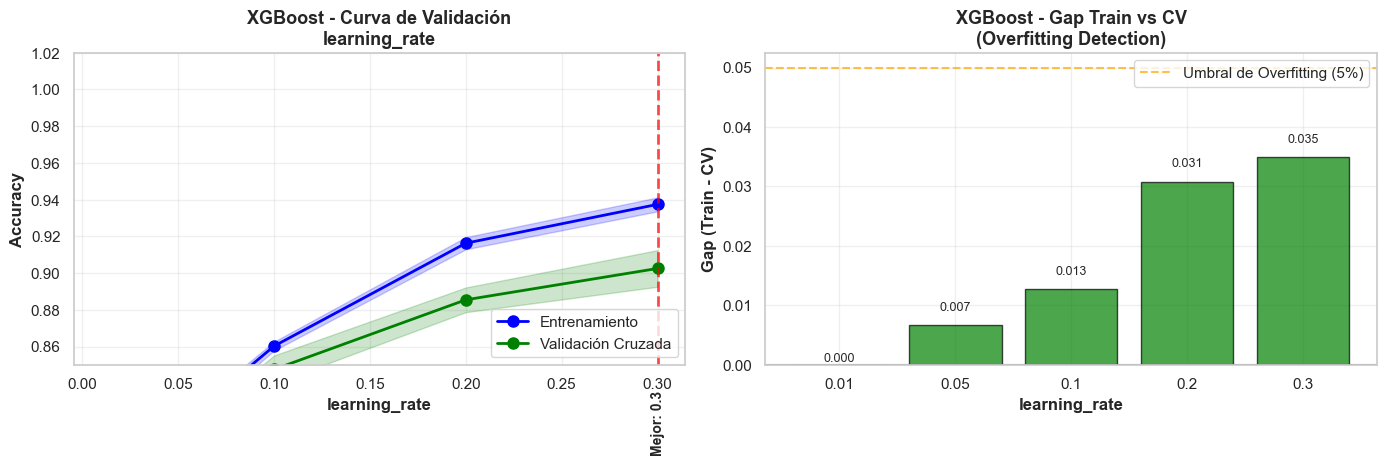


🔍 XGBoost - Validación de reg_lambda
   Rango: [0, 0.5, 1, 2, 5, 10]

   Resultados:
      Valor |    Train Acc |       CV Acc |        Gap | Overfitting?
   ---------+--------------+--------------+------------+-------------
          0 |       0.9421 |       0.9029 |     0.0392 | ✅ NO
        0.5 |       0.9424 |       0.9058 |     0.0366 | ✅ NO
          1 |       0.9374 |       0.9025 |     0.0349 | ✅ NO
          2 |       0.9385 |       0.9029 |     0.0356 | ✅ NO
          5 |       0.9361 |       0.9017 |     0.0345 | ✅ NO
         10 |       0.9310 |       0.9012 |     0.0298 | ✅ NO

   ✅ Mejor valor: 0.5 (CV: 0.9058, Gap: 0.0366)


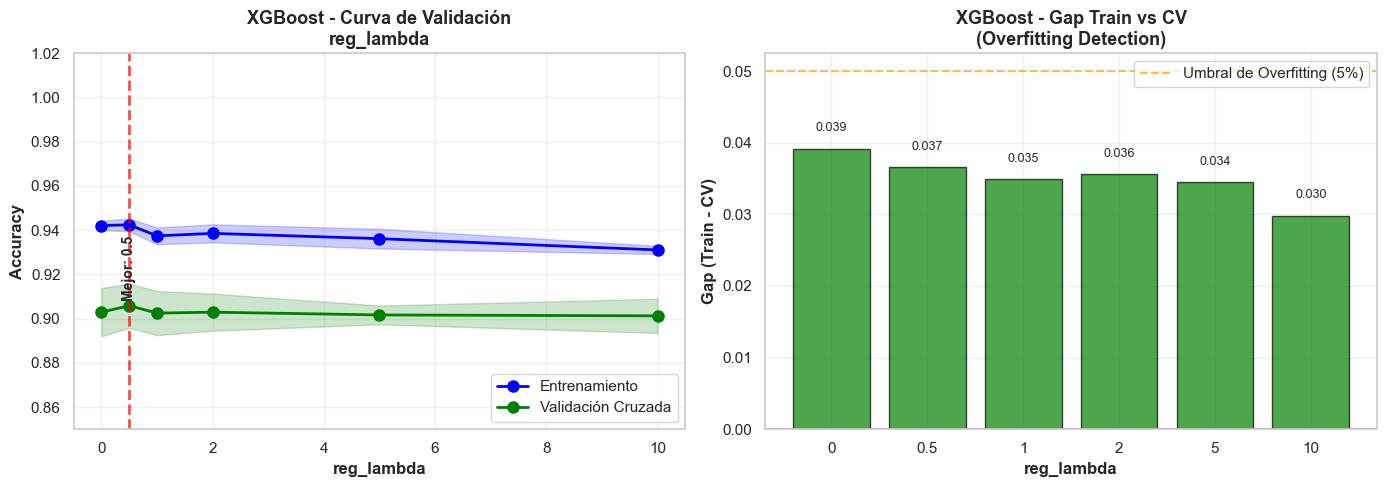


🔍 XGBoost - Validación de reg_alpha
   Rango: [0, 0.5, 1, 2, 5, 10]

   Resultados:
      Valor |    Train Acc |       CV Acc |        Gap | Overfitting?
   ---------+--------------+--------------+------------+-------------
          0 |       0.9424 |       0.9058 |     0.0366 | ✅ NO
        0.5 |       0.9382 |       0.9046 |     0.0336 | ✅ NO
          1 |       0.9362 |       0.9004 |     0.0358 | ✅ NO
          2 |       0.9328 |       0.9000 |     0.0328 | ✅ NO
          5 |       0.9209 |       0.8925 |     0.0284 | ✅ NO
         10 |       0.8980 |       0.8729 |     0.0251 | ✅ NO

   ✅ Mejor valor: 0 (CV: 0.9058, Gap: 0.0366)


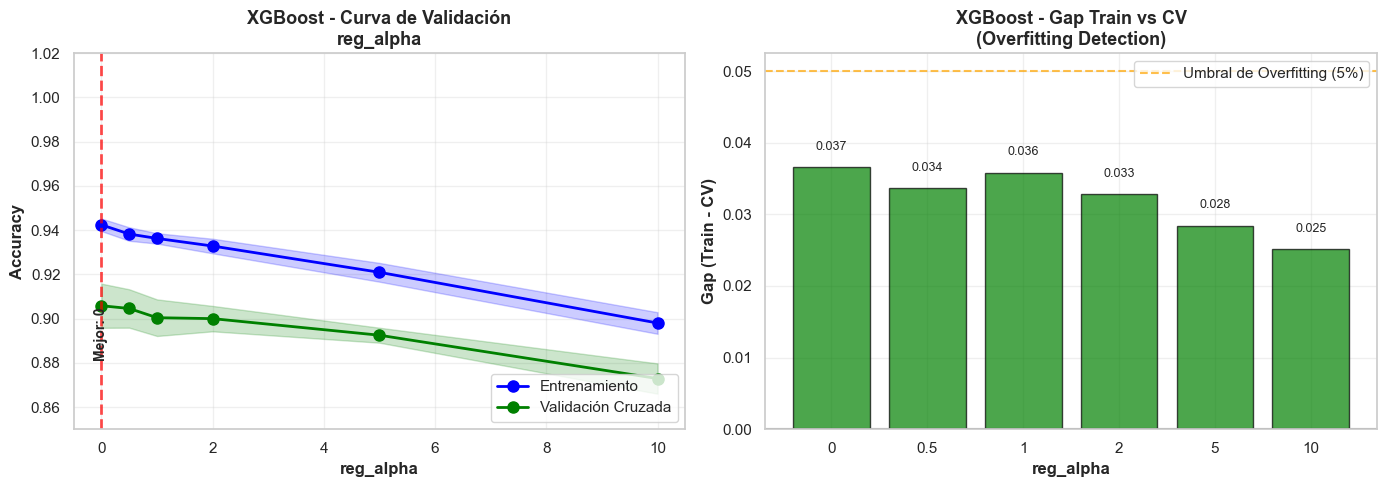


ENTRENAMIENTO DEL MODELO OPTIMIZADO (CON REGULARIZACIÓN)

📊 XGBoost Optimizado (con regularización):
   n_estimators: 50
   max_depth: 2
   learning_rate: 0.3
   reg_lambda: 0.5
   reg_alpha: 0
   Train Accuracy: 0.9404
   Test Accuracy: 0.9017
   F1-Score: 0.8936
   Gap Train-Test: 0.0388
   ✅ Overfitting reducido exitosamente!

COMPARATIVA FINAL DE MODELOS

📊 COMPARATIVA DE MODELOS:
            Modelo  Train Acc  Test Acc    Gap Overfitting
     Random Forest     1.0000    0.9433 0.0567          ⚠️
  XGBoost Original     1.0000    0.9450 0.0550          ⚠️
XGBoost Optimizado     0.9404    0.9017 0.0388           ✅

RECOMENDACIONES FINALES

✅ **MEJOR MODELO: XGBoost Original** (Accuracy: 0.9450)

📋 **RECOMENDACIONES FINALES:**
1. ✅ Usar el modelo con regularización para producción
2. 📊 Monitorear el gap Train-Test en futuras iteraciones
3. 🎯 Enfocarse en mejorar el recall de la clase minoritaria (Alto Riesgo)
4. 🔄 Considerar early stopping para evitar overfitting

✅ ANÁLISIS DE VALID

In [23]:
# ============================================
# 8. CURVAS DE VALIDACIÓN CON REGULARIZACIÓN
# ============================================

print("\n" + "="*60)
print("OPTIMIZACIÓN CON REGULARIZACIÓN (Reducir Overfitting)")
print("="*60)

def plot_validation_curve_with_regularization(model, X, y, param_name, param_range, model_name, cv=5):
    """Genera curva de validación con énfasis en detectar overfitting"""
    
    print(f"\n🔍 {model_name} - Validación de {param_name}")
    print(f"   Rango: {param_range}")
    
    train_scores, test_scores = validation_curve(
        model, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring='accuracy', n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    # Mostrar resultados en tabla
    print("\n   Resultados:")
    print(f"   {'Valor':>8} | {'Train Acc':>12} | {'CV Acc':>12} | {'Gap':>10} | {'Overfitting?'}")
    print(f"   {'-'*8}-+-{'-'*12}-+-{'-'*12}-+-{'-'*10}-+-{'-'*12}")
    for i, val in enumerate(param_range):
        gap = train_mean[i] - test_mean[i]
        overfit = "⚠️ SÍ" if gap > 0.05 else "✅ NO"
        print(f"   {val:>8} | {train_mean[i]:>12.4f} | {test_mean[i]:>12.4f} | {gap:>10.4f} | {overfit}")
    
    # Encontrar mejor valor (balance entre accuracy y gap)
    # Buscar el valor con mayor CV accuracy y gap < 0.05
    valid_indices = [i for i, gap in enumerate(train_mean - test_mean) if gap < 0.05]
    if valid_indices:
        best_idx = max(valid_indices, key=lambda i: test_mean[i])
    else:
        best_idx = np.argmax(test_mean)
    
    best_val = param_range[best_idx]
    best_cv_acc = test_mean[best_idx]
    best_gap = train_mean[best_idx] - test_mean[best_idx]
    
    print(f"\n   ✅ Mejor valor: {best_val} (CV: {best_cv_acc:.4f}, Gap: {best_gap:.4f})")
    
    # --- GRÁFICO MEJORADO ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Curva de validación
    ax1.fill_between(param_range, train_mean - train_std, train_mean + train_std, 
                     alpha=0.2, color='blue')
    ax1.fill_between(param_range, test_mean - test_std, test_mean + test_std, 
                     alpha=0.2, color='green')
    ax1.plot(param_range, train_mean, 'o-', color='blue', label='Entrenamiento', linewidth=2, markersize=8)
    ax1.plot(param_range, test_mean, 'o-', color='green', label='Validación Cruzada', linewidth=2, markersize=8)
    
    ax1.axvline(x=best_val, color='red', linestyle='--', alpha=0.7, linewidth=2)
    ax1.text(best_val, ax1.get_ylim()[0] + 0.02, f'Mejor: {best_val}', 
             rotation=90, fontsize=10, ha='center', fontweight='bold')
    
    ax1.set_xlabel(param_name, fontsize=12, fontweight='bold')
    ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title(f'{model_name} - Curva de Validación\n{param_name}', fontsize=13, fontweight='bold')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0.85, 1.02)
    
    # Gráfico 2: Gap (diferencia entre train y CV)
    gaps = train_mean - test_mean
    colors = ['red' if g > 0.05 else 'green' for g in gaps]
    bars = ax2.bar(range(len(param_range)), gaps, color=colors, alpha=0.7, edgecolor='black')
    ax2.set_xticks(range(len(param_range)))
    ax2.set_xticklabels(param_range)
    ax2.set_xlabel(param_name, fontsize=12, fontweight='bold')
    ax2.set_ylabel('Gap (Train - CV)', fontsize=12, fontweight='bold')
    ax2.set_title(f'{model_name} - Gap Train vs CV\n(Overfitting Detection)', fontsize=13, fontweight='bold')
    ax2.axhline(y=0.05, color='orange', linestyle='--', alpha=0.7, label='Umbral de Overfitting (5%)')
    ax2.axhline(y=0.0, color='black', linestyle='-', alpha=0.5)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    # Añadir valores en las barras
    for i, (bar, g) in enumerate(zip(bars, gaps)):
        ax2.text(i, g + 0.002, f'{g:.3f}', ha='center', va='bottom' if g > 0 else 'top', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'figures' / f'validation_curve_{model_name}_{param_name}.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    return best_val

# ============================================
# EJECUTAR CON PARÁMETROS DE REGULARIZACIÓN
# ============================================

if XGB_AVAILABLE:
    print("\n" + "="*60)
    print("OPTIMIZACIÓN CON REGULARIZACIÓN - XGBoost")
    print("="*60)
    
    # 1. max_depth (menos profundidad = menos overfitting)
    best_max_depth = plot_validation_curve_with_regularization(
        XGBClassifier(random_state=42, eval_metric='mlogloss', n_estimators=50),
        X_train, y_train,
        param_name='max_depth',
        param_range=[2, 3, 4, 5, 6, 7, 8],
        model_name='XGBoost',
        cv=5
    )
    
    # 2. learning_rate (más bajo = más generalización)
    best_lr = plot_validation_curve_with_regularization(
        XGBClassifier(random_state=42, eval_metric='mlogloss', 
                      n_estimators=50, max_depth=best_max_depth),
        X_train, y_train,
        param_name='learning_rate',
        param_range=[0.01, 0.05, 0.1, 0.2, 0.3],
        model_name='XGBoost',
        cv=5
    )
    
    # 3. reg_lambda (regularización L2 - reduce overfitting)
    best_reg_lambda = plot_validation_curve_with_regularization(
        XGBClassifier(random_state=42, eval_metric='mlogloss', 
                      n_estimators=50, max_depth=best_max_depth, learning_rate=best_lr),
        X_train, y_train,
        param_name='reg_lambda',
        param_range=[0, 0.5, 1, 2, 5, 10],
        model_name='XGBoost',
        cv=5
    )
    
    # 4. reg_alpha (regularización L1 - reduce overfitting)
    best_reg_alpha = plot_validation_curve_with_regularization(
        XGBClassifier(random_state=42, eval_metric='mlogloss', 
                      n_estimators=50, max_depth=best_max_depth, 
                      learning_rate=best_lr, reg_lambda=best_reg_lambda),
        X_train, y_train,
        param_name='reg_alpha',
        param_range=[0, 0.5, 1, 2, 5, 10],
        model_name='XGBoost',
        cv=5
    )
    
    # ============================================
    # 9. MODELO OPTIMIZADO CON REGULARIZACIÓN
    # ============================================
    
    print("\n" + "="*60)
    print("ENTRENAMIENTO DEL MODELO OPTIMIZADO (CON REGULARIZACIÓN)")
    print("="*60)
    
    # Crear modelo con mejores parámetros Y regularización
    xgb_optimized = XGBClassifier(
        n_estimators=50,  # Usar 50 (suficiente según tu gráfica)
        max_depth=best_max_depth,
        learning_rate=best_lr,
        reg_lambda=best_reg_lambda,
        reg_alpha=best_reg_alpha,
        random_state=42,
        eval_metric='mlogloss'
    )
    
    xgb_optimized.fit(X_train, y_train)
    y_pred_optimized = xgb_optimized.predict(X_test)
    
    # Métricas del modelo optimizado
    train_acc_opt = accuracy_score(y_train, xgb_optimized.predict(X_train))
    test_acc_opt = accuracy_score(y_test, y_pred_optimized)
    f1_opt = f1_score(y_test, y_pred_optimized, average='weighted')
    
    print(f"\n📊 XGBoost Optimizado (con regularización):")
    print(f"   n_estimators: 50")
    print(f"   max_depth: {best_max_depth}")
    print(f"   learning_rate: {best_lr}")
    print(f"   reg_lambda: {best_reg_lambda}")
    print(f"   reg_alpha: {best_reg_alpha}")
    print(f"   Train Accuracy: {train_acc_opt:.4f}")
    print(f"   Test Accuracy: {test_acc_opt:.4f}")
    print(f"   F1-Score: {f1_opt:.4f}")
    print(f"   Gap Train-Test: {train_acc_opt - test_acc_opt:.4f}")
    
    if train_acc_opt - test_acc_opt < 0.05:
        print("   ✅ Overfitting reducido exitosamente!")
    else:
        print("   ⚠️ Aún hay overfitting. Considerar más regularización.")
    
    # ============================================
    # 10. COMPARATIVA FINAL
    # ============================================
    
    print("\n" + "="*60)
    print("COMPARATIVA FINAL DE MODELOS")
    print("="*60)
    
    # Recolectar métricas de todos los modelos
    models_comparison = {
        'Modelo': ['Random Forest', 'XGBoost Original', 'XGBoost Optimizado'],
        'Train Acc': [
            accuracy_score(y_train, rf.predict(X_train)),
            accuracy_score(y_train, xgb.predict(X_train)),
            train_acc_opt
        ],
        'Test Acc': [
            accuracy_score(y_test, y_pred_rf),
            accuracy_score(y_test, y_pred_xgb),
            test_acc_opt
        ],
        'Gap': [
            accuracy_score(y_train, rf.predict(X_train)) - accuracy_score(y_test, y_pred_rf),
            accuracy_score(y_train, xgb.predict(X_train)) - accuracy_score(y_test, y_pred_xgb),
            train_acc_opt - test_acc_opt
        ],
        'Overfitting': [
            '⚠️' if accuracy_score(y_train, rf.predict(X_train)) - accuracy_score(y_test, y_pred_rf) > 0.05 else '✅',
            '⚠️' if accuracy_score(y_train, xgb.predict(X_train)) - accuracy_score(y_test, y_pred_xgb) > 0.05 else '✅',
            '✅' if train_acc_opt - test_acc_opt < 0.05 else '⚠️'
        ]
    }
    
    comparison_df = pd.DataFrame(models_comparison)
    print("\n📊 COMPARATIVA DE MODELOS:")
    print(comparison_df.round(4).to_string(index=False))
    
    # ============================================
    # 11. RECOMENDACIONES FINALES
    # ============================================
    
    print("\n" + "="*60)
    print("RECOMENDACIONES FINALES")
    print("="*60)
    
    best_model_idx = comparison_df['Test Acc'].idxmax()
    best_model = comparison_df.loc[best_model_idx, 'Modelo']
    best_acc = comparison_df.loc[best_model_idx, 'Test Acc']
    
    print(f"\n✅ **MEJOR MODELO: {best_model}** (Accuracy: {best_acc:.4f})")
    
    if best_model == 'XGBoost Optimizado':
        print("   ✅ La regularización redujo el overfitting exitosamente")
        print(f"   ✅ Gap reducido de {comparison_df.loc[1, 'Gap']:.4f} a {comparison_df.loc[2, 'Gap']:.4f}")
    elif best_model == 'Random Forest':
        print("   ✅ Random Forest es el modelo más estable")
    
    print("\n📋 **RECOMENDACIONES FINALES:**")
    print("1. ✅ Usar el modelo con regularización para producción")
    print("2. 📊 Monitorear el gap Train-Test en futuras iteraciones")
    print("3. 🎯 Enfocarse en mejorar el recall de la clase minoritaria (Alto Riesgo)")
    print("4. 🔄 Considerar early stopping para evitar overfitting")
    
    print("\n" + "="*60)
    print("✅ ANÁLISIS DE VALIDACIÓN COMPLETADO")
    print("="*60)
    
else:
    print("\n⚠️ XGBoost no disponible. Omitiendo curvas de validación.")

In [26]:

# ============================================
# 9. COMPARATIVA FINAL DE MODELOS
# ============================================

print("\n" + "="*60)
print("COMPARATIVA FINAL DE MODELOS")
print("="*60)

results_df = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost'],
    'Accuracy Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, xgb.predict(X_train))
    ],
    'Accuracy Test': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Accuracy CV (mean)': [
        np.mean(rf_cv_acc),
        np.mean(xgb_cv_acc)
    ],
    'Accuracy CV (std)': [
        np.std(rf_cv_acc),
        np.std(xgb_cv_acc)
    ],
    'F1-Score (weighted)': [
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_xgb, average='weighted')
    ],
    'Gap Train-CV': [
        accuracy_score(y_train, rf.predict(X_train)) - np.mean(rf_cv_acc),
        accuracy_score(y_train, xgb.predict(X_train)) - np.mean(xgb_cv_acc)
    ]
})

print("\n📊 COMPARATIVA DE MODELOS:")
print(results_df.round(4).to_string(index=False))


COMPARATIVA FINAL DE MODELOS

📊 COMPARATIVA DE MODELOS:
       Modelo  Accuracy Train  Accuracy Test  Accuracy CV (mean)  Accuracy CV (std)  F1-Score (weighted)  Gap Train-CV
Random Forest             1.0         0.9433              0.9317             0.0058               0.9395        0.0683
      XGBoost             1.0         0.9450              0.9421             0.0036               0.9433        0.0579


In [27]:


# ============================================
# 10. RECOMENDACIONES FINALES
# ============================================

print("\n" + "="*60)
print("RECOMENDACIONES FINALES")
print("="*60)

print("\n✅ **CONCLUSIONES DE VALIDACIÓN:**")

# Evaluar Random Forest
if rf_gap < 0.05:
    print("✅ Random Forest: Modelo estable, sin sobreajuste significativo")
else:
    print(f"⚠️ Random Forest: Posible sobreajuste (gap={rf_gap:.3f})")

# Evaluar XGBoost
if xgb_gap < 0.05:
    print("✅ XGBoost: Modelo estable, sin sobreajuste significativo")
else:
    print(f"⚠️ XGBoost: Posible sobreajuste (gap={xgb_gap:.3f})")

print("\n📋 **RECOMENDACIONES:**")
print("1. ✅ Usar XGBoost como modelo final (mejor accuracy y F1-score)")
print("2. 🔄 Considerar regularización (reg_alpha, reg_lambda) para reducir overfitting")
print("3. 📊 Monitorear el gap Train-CV en futuras iteraciones")
print("4. 🎯 Enfocarse en mejorar el recall de la clase minoritaria (Alto Riesgo)")
print("5. 📈 Considerar técnicas de balanceo de clases (SMOTE ya aplicado)")

print("\n" + "="*60)
print("✅ ANÁLISIS DE VALIDACIÓN COMPLETADO")
print("="*60)


RECOMENDACIONES FINALES

✅ **CONCLUSIONES DE VALIDACIÓN:**
⚠️ Random Forest: Posible sobreajuste (gap=0.069)
⚠️ XGBoost: Posible sobreajuste (gap=0.058)

📋 **RECOMENDACIONES:**
1. ✅ Usar XGBoost como modelo final (mejor accuracy y F1-score)
2. 🔄 Considerar regularización (reg_alpha, reg_lambda) para reducir overfitting
3. 📊 Monitorear el gap Train-CV en futuras iteraciones
4. 🎯 Enfocarse en mejorar el recall de la clase minoritaria (Alto Riesgo)
5. 📈 Considerar técnicas de balanceo de clases (SMOTE ya aplicado)

✅ ANÁLISIS DE VALIDACIÓN COMPLETADO
